# [UEA-EST] Mineração de Dados — Rating Prediction Challenge 2026
- Disciplina: Mineração de Dados;
- Equipe:
  - Pedro Yutaro Mont Morency Nakamura (pymmn.snf23@uea.edu.br)
  - Lucas Carvalho Dos Santos (lcds.snf23@uea.edu.br)
  - Matheus De Almeida Damgaard Nielsen (mdadn.eng20@uea.edu.br)
- Data: 18 de Março de 2026;
- Repositório: https://github.com/PedroYutaroUEA/rating-prediction-challenge/

# 1. Introdução e Objetivo
Descreva brevemente o problema: Classificação multiclasse de reviews em português (ratings de 1 a 5). O objetivo é maximizar o F1 Score.

# 2. Importações, Configuração de Ambiente e Carga de Dados

In [23]:
import os
import pandas as pd
import numpy as np

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns

# Processamento de Linguagem Natural (NLP)
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import spacy

# Classificadores
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

## 2.1 Configuração de gráficos

In [24]:
# Configurações de visualização
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 2.2 Carregamento do modelo SpaCy para Português

In [25]:
try:
    nlp = spacy.load("pt_core_news_lg")
    print("✅ SpaCy pt_core_news_lg carregado com sucesso!")
except:
    print("❌ Erro ao carregar o modelo. Verifique a instalação.")

✅ SpaCy pt_core_news_lg carregado com sucesso!


## 2.3 Importação dos datasets

In [26]:
# Dados de treinamento
train_df = pd.read_csv('./datasets/train.csv')
# Dados de teste
test_df = pd.read_csv('./datasets/test.csv')
# Dados brutos
sample_df = pd.read_csv('./datasets/sample_submission.csv')

# 3. Análise Exploratória de Dados (E.D.A)

## Definição dos datasets + Significado de cada coluna

- <b>train.csv: </b> Conjunto de treino (contém a variável alvo rating).
    - id: identificador único do exemplo.
    - ASIN: identificador do item/produto.
    - title: título do review.
    - text: texto do review.
    - rating: alvo (classe 1 a 5).
- <b>test.csv: </b> Conjunto de teste (não contém rating).
    - id: identificador único do exemplo.
    - ASIN: identificador do item/produto.
    - title: título do review.
    - text: texto do review.
- <b>sample_submission.csv: </b> Exemplo do arquivo de submissão no formato correto.
    - id: identificador único do exemplo (igual ao test.csv).
    - rating: classe prevista (1 a 5).

## Verificações necessárias:

- Visto que a métrica principal é o F1 score:
    - O quão ausentes são os dados nos datasets?
    - As classes targets são proporcionalmente distribuídas?
    - O tamanho do texto varia muito em razão da avaliação?
    - O conteúdo do título é tão impactante quanto o conteúdo do texto na determinação da classe?

## 3.1 Visualização dos Dados

In [27]:
train_df.head()

,id,ASIN,text,title,rating
0,17578,B07FSVFWDS,"Por incrível que pareça, para uma bebida desti...",Vodka diferenciada,5
1,18658,B08ZHC4VNJ,"O readset pode até ser bom, mais tem outros fo...",Absurdo,1
2,28477,8545202539,"Foi difícil terminar esse livro , demorou mese...",Decepção,2
3,43638,B0081Z77YI,"A bola é boa divertida, mas não é nem um pouco...","Não é indicada para cães grandes, nem mesmo a ...",2
4,26130,857860184X,Comprei errado! Não tenho leitor de e-books. Q...,Enganei,1


In [28]:
test_df.head()

,id,ASIN,text,title
0,40261,B08N35PKW4,É bonzinho pelo preço.,.
1,46176,B07BH4QFYH,Muito bruto e já desmontou,Som ruim.
2,47942,B07FMBW1VP,O tabuleiro é bonito e as peças grandes. Mas ...,Faltou uma peça
3,37329,B07VKYGQ2V,O tamanho GG veio equivalente a um M. Foi um p...,Reclamação
4,13503,B086CXR646,qualidade imagem e facilidade de uso.,a utilidade muito boa


In [29]:
sample_df.head()

,id,rating
0,40261,3
1,46176,3
2,47942,3
3,37329,3
4,13503,3


### 3.1.1 Contagem de valores nulos e tipos

In [30]:
print('\n<===== TRAIN DATAFRAME =====>')
train_df.info()

print('\n<===== TEST DATAFRAME =====>')
test_df.info()

print('\n<===== SAMPLE DATAFRAME =====>')
sample_df.info()


<===== TRAIN DATAFRAME =====>
<class 'pandas.DataFrame'>
RangeIndex: 41005 entries, 0 to 41004
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      41005 non-null  int64
 1   ASIN    41005 non-null  str  
 2   text    41004 non-null  str  
 3   title   41002 non-null  str  
 4   rating  41005 non-null  int64
dtypes: int64(2), str(3)
memory usage: 1.6 MB

<===== TEST DATAFRAME =====>
<class 'pandas.DataFrame'>
RangeIndex: 10252 entries, 0 to 10251
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      10252 non-null  int64
 1   ASIN    10252 non-null  str  
 2   text    10251 non-null  str  
 3   title   10251 non-null  str  
dtypes: int64(1), str(3)
memory usage: 320.5 KB

<===== SAMPLE DATAFRAME =====>
<class 'pandas.DataFrame'>
RangeIndex: 10252 entries, 0 to 10251
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  ---

## 3.2 Análise da distribuição entre as classes

### 3.2.1 Verificando classes nulas

In [31]:
print("\nValores ausentes:\n", train_df.isnull().sum())


Valores ausentes:
 id        0
ASIN      0
text      1
title     3
rating    0
dtype: int64


### 3.2.2 Distribuição das Classes (Ratings)

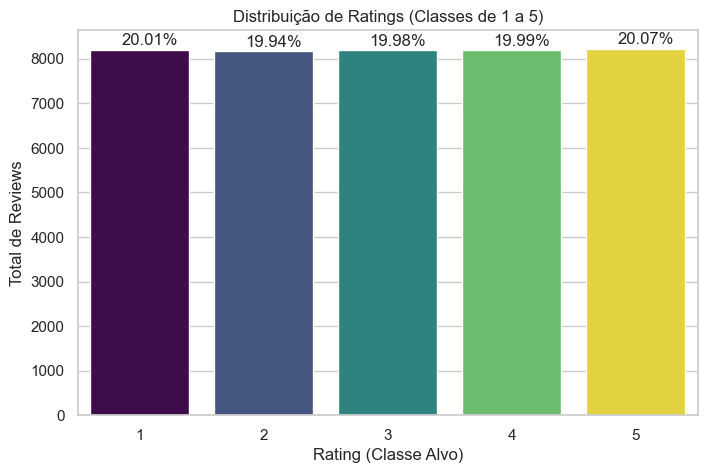

In [32]:
# Fundamental para verificar o desbalanceamento 
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='rating', hue='rating', palette='viridis', legend=False)

plt.title('Distribuição de Ratings (Classes de 1 a 5)')
plt.xlabel('Rating (Classe Alvo)')
plt.ylabel('Total de Reviews')

# Adicionando porcentagens nas barras
total = len(train_df)
for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height()/total)
    ax.annotate(percentage, (p.get_x() + 0.25, p.get_height() + 100))
plt.show()

### 3.2.3 Análise de Comprimento do Texto e Título (Structural Features)

In [33]:
# É mencionado no artigo que sentenças factuais podem ser mais curtas
def show_content_len_by_class(doc="text", q=0.95):
    train_df['doc_len'] = train_df[doc].str.split().str.len()

    plt.figure(figsize=(8, 5))

    sns.boxplot(data=train_df, x='rating', hue='rating', y='doc_len', palette='viridis', legend=False)

    plt.title(f'Comprimento do "{doc}" por Rating (Contagem de Palavras)')
    plt.xlabel('Rating')
    plt.ylabel('Número de Palavras')

    plt.ylim(0, train_df['doc_len'].quantile(q)) # Remove outliers para melhor visualização
    plt.show()

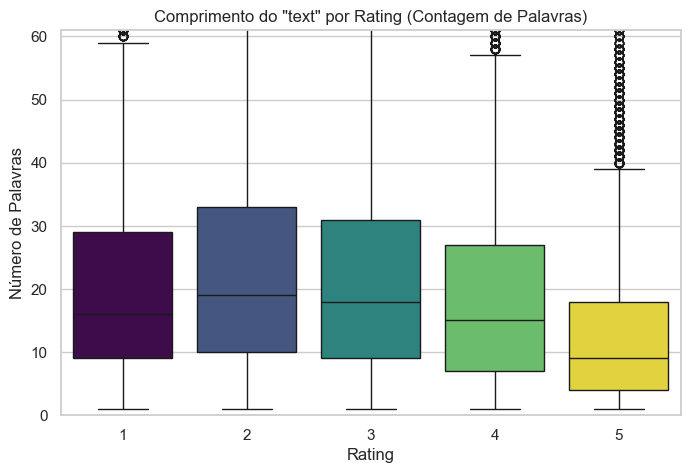

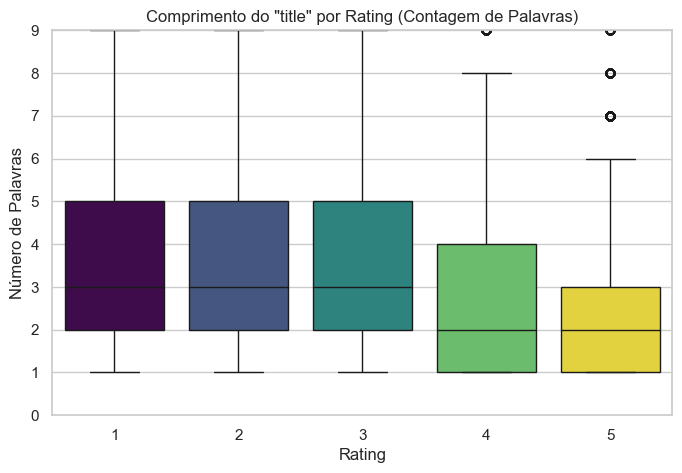

In [34]:
show_content_len_by_class(doc="text")
show_content_len_by_class(doc="title")

## 3.3 Termos mais frequentes por classe 

Objetivo: intuição (Comparar frequências de adjetivos no Título vs. Texto.)

Aqui será usado a estratégia de BoW para visualizar os termos mais frequentes por ratting.

doc -> tokenização -> vocab token dict -> sparse matrix

In [35]:
stop_words_pt = list(nlp.Defaults.stop_words)

def plot_top_ngrams(df, rating, n=2, top_k=10, doc='text'):
    subset = df[df['rating'] == rating].copy()
    # Filtrar apenas o rating específico
    text_data = subset[doc].fillna('').astype(str).str.lower()
    
    # Configurar o vetorizador para Bigrams (n=2)
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words=stop_words_pt
    ).fit(text_data)
    
    bag_of_words = vec.transform(text_data)
    
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    # Plotar
    top_df = pd.DataFrame(words_freq[:top_k], columns=['Termo', 'Frequência'])

    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_df, x='Frequência', hue='Frequência', y='Termo', palette='viridis', legend=False)
    plt.title(f'Top {top_k} Bigrams para Rating {rating} com base no "{doc}":')
    plt.show()

    return top_df

### 3.3.1 Termos mais frequentes por texto

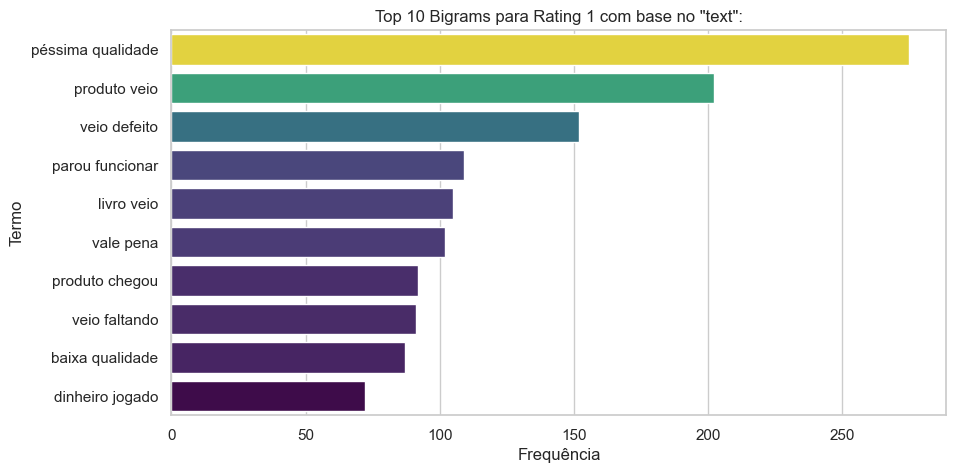

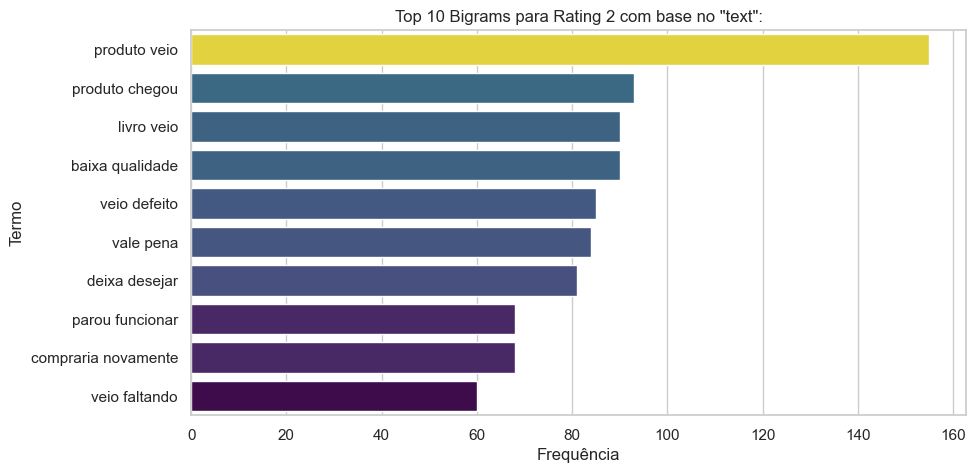

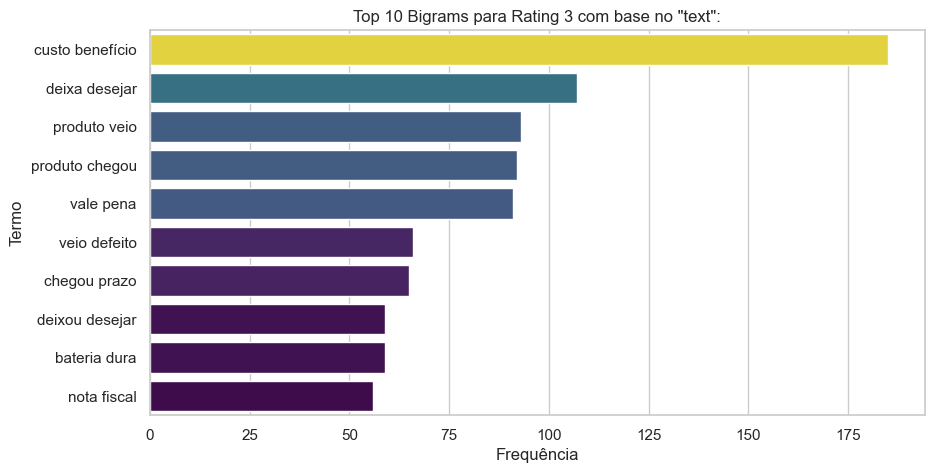

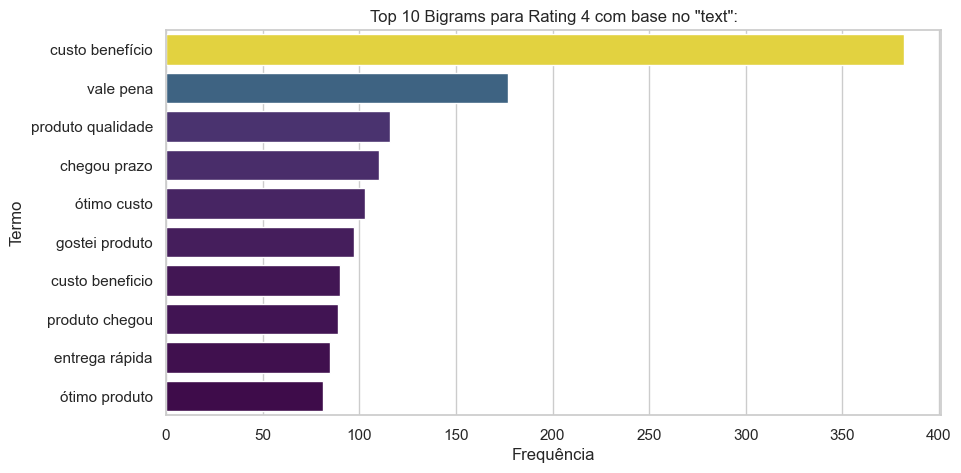

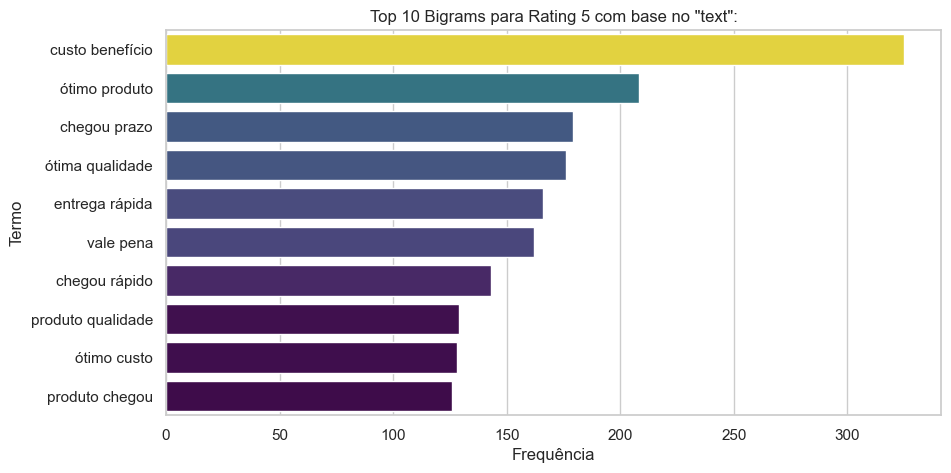

In [36]:
text_freq_dict = {}

for i in range(train_df['rating'].min(), train_df['rating'].max() + 1):
    df = plot_top_ngrams(train_df, rating=i)
    text_freq_dict[i] = df

### 3.3.2 Termos mais frequentes por título

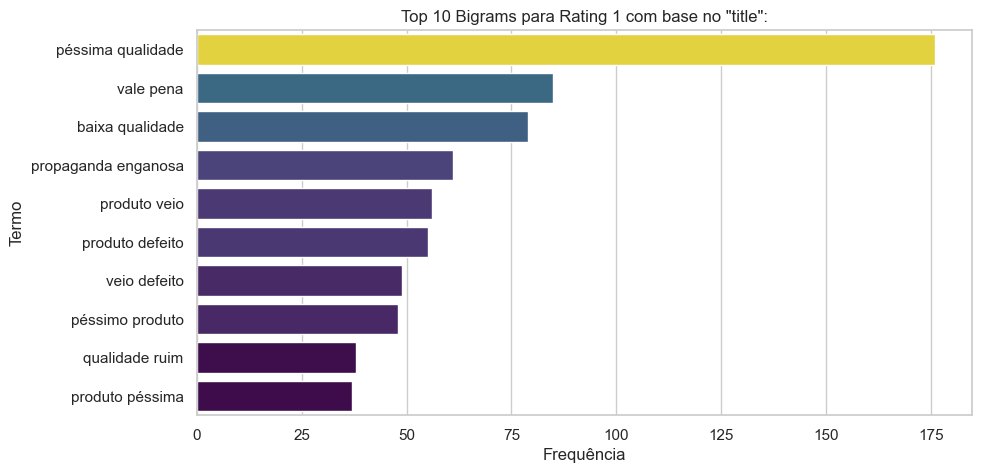

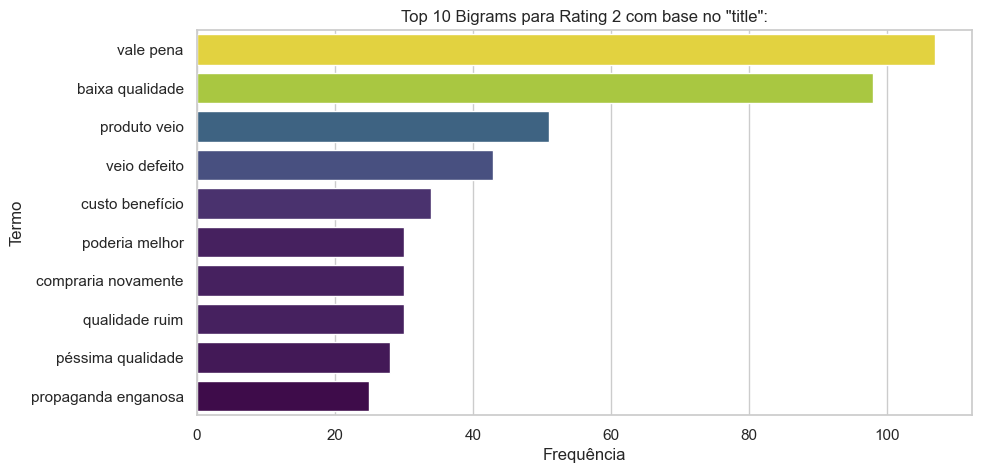

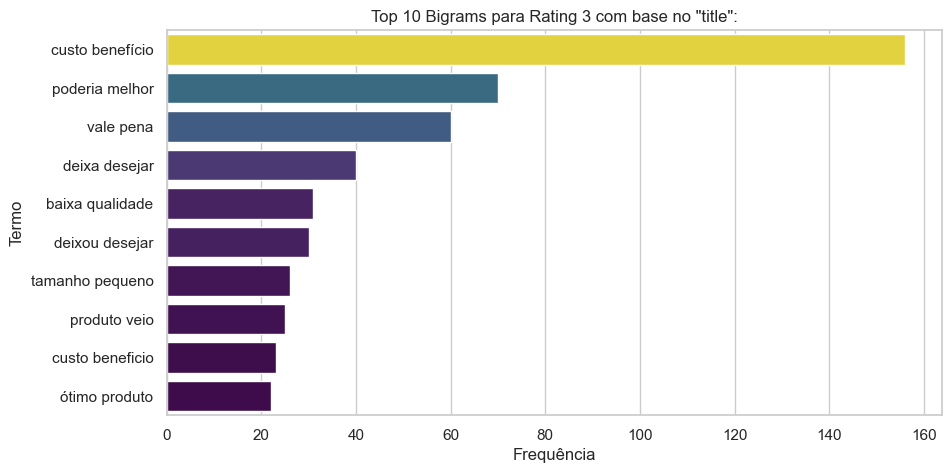

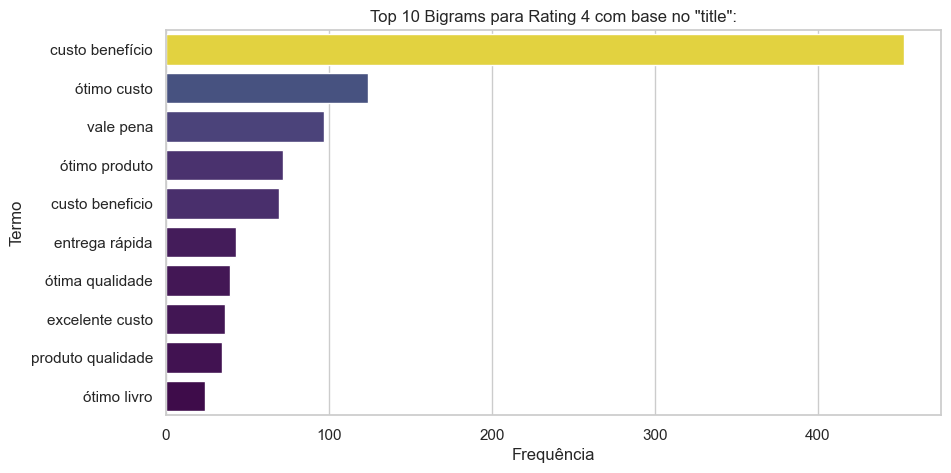

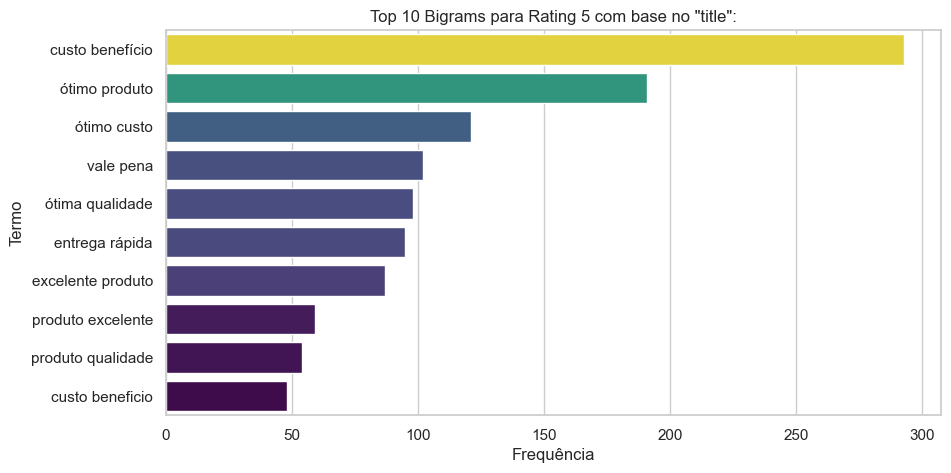

In [37]:
title_freq_dict = {}

for i in range(train_df['rating'].min(), train_df['rating'].max() + 1):
    df = plot_top_ngrams(train_df, rating=i, doc='title')
    title_freq_dict[i] = df

## 3.4 Resultado da análise inicial

### Sobre a ausência e distribuição dos dados:
É possível notar que a distribuição das classes estão bem equilibradas. Os valores no datasets são raramente nulos (apenas 1 texto e 3 títulos estão faltando/vazios).

### Sobre o comprimento do conteúdo em razão do ratting:
O comprimento da sentença do título e do texto em razão do ratting assumem um padrão semelhante no geral, ambos com rattings de 4 e 5 com um número relativamente menor de palavras em relação as outras classes.

### Sobre os termos mais frequentes em razão do ratting:

# 4 Pré-processamento de Texto (NLP Pipeline)

Limpeza dos dados: remoção de stop words, pontuação, stemização/lemmatização e tratamento de valores ausentes (se houver).

In [38]:
def preprocess_text_spacy(texts):
    # Trata valores ausentes e converte para string
    texts = texts.fillna('').astype(str)
    
    # Utiliza o nlp.pipe para processamento em lote (mais rápido)
    # Desabilita 'ner' e 'parser' pois não são precisos para lemmatizar/limpar, ganhando desempenho
    clean_texts = []
    for doc in nlp.pipe(texts, disable=['ner', 'parser']):
        # Lemmatização, remoção de stopwords, pontuações e espaços em branco
        tokens = [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space]
        clean_texts.append(" ".join(tokens))
        
    return clean_texts


## 4.1 Pré-processamento de dados de treino

In [39]:
print("Processando dados de treino...")
train_df['text_clean'] = preprocess_text_spacy(train_df['text'])
train_df['title_clean'] = preprocess_text_spacy(train_df['title'])

Processando dados de treino...


## 4.2 Pré-processamento de dados de teste

In [40]:
print("Processando dados de teste...")
test_df['text_clean'] = preprocess_text_spacy(test_df['text'])
test_df['title_clean'] = preprocess_text_spacy(test_df['title'])

Processando dados de teste...


# 4.3. Resultado do pré-processamento

In [41]:
print("Pré-processamento concluído!")
train_df[['text', 'text_clean', 'title', 'title_clean']].head()

Pré-processamento concluído!


,text,text_clean,title,title_clean
0,"Por incrível que pareça, para uma bebida desti...",incrível parecer bebida destilar alto concentr...,Vodka diferenciada,vodka diferenciar
1,"O readset pode até ser bom, mais tem outros fo...",readset fone custar barato faixa r$ 600 r$ 700...,Absurdo,absurdo
2,"Foi difícil terminar esse livro , demorou mese...",difícil terminar livro demorar cansativo práti...,Decepção,decepção
3,"A bola é boa divertida, mas não é nem um pouco...",bola divertido resistente valer preço durar ab...,"Não é indicada para cães grandes, nem mesmo a ...",indicar cão bola
4,Comprei errado! Não tenho leitor de e-books. Q...,comprei errar leitor e-books queria livro físi...,Enganei,enganei


# 5 Engenharia de Features e Vetorização

Transformação do texto em números (TF-IDF, Bag of Words ou Word Embeddings).

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("Vetorizando os dados com TF-IDF...")

Vetorizando os dados com TF-IDF...


## 5.1 Combinação de título e texto limpos para captura de informações

In [43]:
train_combined = train_df['title_clean'] + " " + train_df['text_clean']
test_combined = test_df['title_clean'] + " " + test_df['text_clean']

## 5.2 Inicialização do TfidVectorizer

In [44]:
# max_features=10000 limita o vocabulário para evitar o uso excessivo de memória,
# ngram_range=(1,2) ajuda a capturar bigramas importantes como 'não funciona'
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

## 5.3 Fit no treino e transformação de treino e teste

In [45]:
X_train_tfidf = tfidf_vectorizer.fit_transform(train_combined)
X_test_tfidf = tfidf_vectorizer.transform(test_combined)

## 5.4. Separação do vetor alvo (y)

In [50]:
y_train = train_df['rating']

## 5. Resultado da vetorização

In [51]:
print(f"Shape da matriz de treino: {X_train_tfidf.shape}")
print(f"Shape da matriz de teste: {X_test_tfidf.shape}")

Shape da matriz de treino: (41005, 10000)
Shape da matriz de teste: (10252, 10000)


# 6 Estratégia de Validação e Treinamento

Definição da técnica de validação (ex: Stratified K-Fold) para evitar data leakage e garantir que o modelo generalize bem para o Private Leaderboard.

# 7 Seleção e Tuning de Modelos

Teste de diferentes algoritmos (Ex: Naive Bayes, SVM, Random Forest, XGBoost ou BERT) e ajuste de hiperparâmetros.

In [47]:
model = XGBClassifier(tree_method='gpu_hist', n_jobs=-1)

In [48]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)


# 8 Avaliação de Resultados e Métricas

Cálculo do F1 Score (Macro/Weighted), Matriz de Confusão e Relatório de Classificação.

# 9 Análise de Erros

Investigação qualitativa: em quais classes o modelo mais erra? Por que o modelo confunde um review nota 2 com nota 1?

# 10 Geração do Arquivo de Submissão

Aplicação do modelo final no test.csv e exportação para submission.csv no formato exigido.

# 11 Metodologia e Conclusões

Resumo da abordagem utilizada, principais desafios encontrados e justificativa das escolhas técnicas para o seminário.